# Laboratori 07: Koha e Reagimit – Të Dhëna, Shpërndarje dhe Probabilitet

**Kursi:** Hyrje Laborator ( Fizike dhe Shkenca Kompjuterike)

**Studenti:** Klaus Dragjoshi

**Data:** 22.04.2026

## 1. Qëllimi i Laboratorit
Qëllimi i këtij laboratori është të tregojë se rezultatet eksperimentale nuk përshkruhen gjithmonë nga një vlerë e vetme, por nga një shpërndarje probabiliteti.

*Studentët do të:*
* Mbledhin një numër të madh të dhënash (30-50 matje).
* Ndërtojnë histogramin e shpërndarjes së kohës.
* Krahasojnë shpërndarjen eksperimentale me një funksion teorik probabiliteti (Shpërndarjen Normale).

## 2. Detyra dhe Procedura

### Procedura e mbledhjes së të dhënave:
1. *Mbledhja e të dhënave:* Punojmë në çifte për të matur distancën e kapjes së vizores në centimetra (cm).
2. *Konvertimi:* Të gjitha distancat konvertohen në metra dhe më pas në kohë (sekonda) duke përdorur formulën e rënies së lirë.
3. *Dataseti:* Ndërtohet dataseti i strukturuar: $$t_1, t_2, ..., t_N$$

### Analiza Statistikore:
* *Llogaritja e Mesatares:* $$\bar{t} = \frac{1}{N}\sum t_i$$
* *Llogaritja e Devijimit Standard:* $$\sigma = \sqrt{\frac{1}{N-1}\sum (t_i - \bar{t})^2}$$
* *Normalizimi:* Histogrami normalizohet në mënyrë që sipërfaqja totale të jetë 1, duke e kthyer atë në një densitet probabiliteti.
* *Krahasimi me Shpërndarjen Normale:* Vendoset kurba Gaussiane mbi histogram për krahasim vizual:
$$f(t) \sim \exp\left(-\frac{(t - \bar{t})^2}{2\sigma^2}\right)$$

Numri i matjeve: 38
Mesatarja (t_bar): 0.1387 s
Devijimi Standard (sigma): 0.0367 s
Rezultati Final: t = (0.139 ± 0.037) s


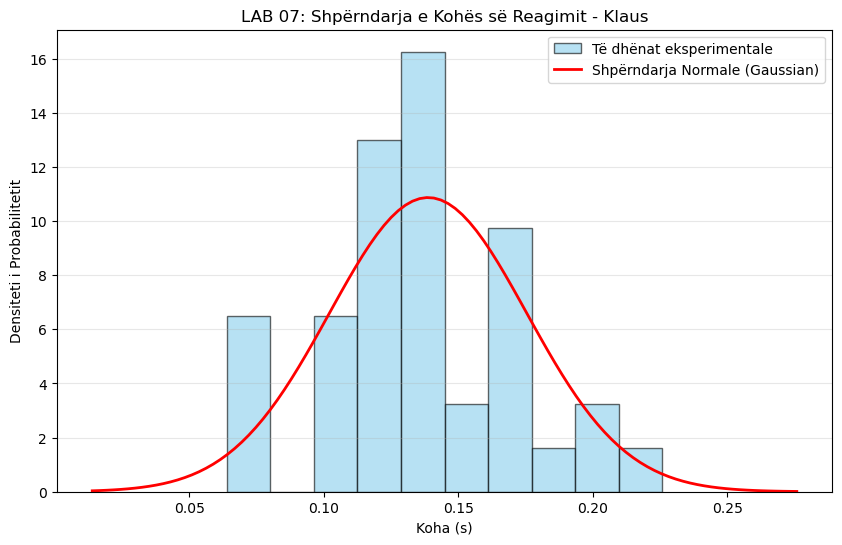

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Matjet e nxjerra nga kolona "Klaus" (në cm)
distancat_cm = [
    15, 10, 14, 20, 15, 11, 20, 10, 10, 8, 
    10, 5, 12, 2, 8, 3, 9, 3, 15, 3, 
    9, 5, 25, 7, 10, 8, 5, 10, 8, 7, 
    5, 9, 7, 15, 10, 17, 15, 8
]

# 2. Konvertimi në metra dhe llogaritja e kohës t = sqrt(2d/g)
d = np.array(distancat_cm) / 100
g = 9.81
t = np.sqrt((2 * d) / g)

# 3. Llogaritjet statistikore
N = len(t)
mesatarja = np.mean(t)
std_dev = np.std(t, ddof=1)

# Printimi i rezultateve për t'i parë në konsolë
print(f"Numri i matjeve: {N}")
print(f"Mesatarja (t_bar): {mesatarja:.4f} s")
print(f"Devijimi Standard (sigma): {std_dev:.4f} s")
print(f"Rezultati Final: t = ({mesatarja:.3f} ± {std_dev:.3f}) s")

# 4. Ndërtimi i grafikut (Histogrami + Kurba Gaussiane)
plt.figure(figsize=(10, 6))

# Histogrami i normalizuar (density=True bën që sipërfaqja të jetë 1)
count, bins, ignored = plt.hist(t, bins=10, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Të dhënat eksperimentale')

# Kurba teorike Gaussiane
x = np.linspace(min(t) - 0.05, max(t) + 0.05, 100)
p = norm.pdf(x, mesatarja, std_dev)
plt.plot(x, p, 'r', linewidth=2, label='Shpërndarja Normale (Gaussian)')

plt.title('LAB 07: Shpërndarja e Kohës së Reagimit - Klaus')
plt.xlabel('Koha (s)')
plt.ylabel('Densiteti i Probabilitetit')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 3. Rezultati Përfundimtar
Pas përpunimit të të dhëna tona, rezultati i kohës së reagimit jepet në formën:

$$t = (\bar{t} \pm \sigma) \, \text{s}$$

*Interpretimi:*
Matjet tregojnë një variacion të dukshëm midis provave, gjë që vërteton se koha e reagimit nuk është konstante por ndjek një shpërndarje të qartë statistikore.